# SAMSum dataset exploration

This notebook examines the standard SAMSum splits before any modelling. It uses whitespace-delimited word counts as a simple, reproducible length proxy; these are not the later model-tokenizer lengths.

In [ ]:
import sys
!{sys.executable} -m pip install torch datasets numpy pandas matplotlib tqdm rouge-score

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import DATASET_NAME, load_samsum

dataset = load_samsum()
print(f'Dataset: {DATASET_NAME}')
dataset

C:\Users\Omar\Desktop\NN Project\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset: knkarthick/samsum


DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})

## Split sizes and schema

In [2]:
for split_name, split in dataset.items():
    print(f'{split_name:>10}: {len(split):,} examples | columns: {split.column_names}')

     train: 14,731 examples | columns: ['id', 'dialogue', 'summary']
validation: 818 examples | columns: ['id', 'dialogue', 'summary']
      test: 819 examples | columns: ['id', 'dialogue', 'summary']


## Dialogue–summary examples

In [3]:
for index in [0, 1, 20]:
    example = dataset['train'][index]
    print(f"Example {index} (id={example['id']})")
    print('Dialogue:')
    print(example['dialogue'])
    print('\nReference summary:')
    print(example['summary'])
    print('\n' + '=' * 80 + '\n')

Example 0 (id=13818513)
Dialogue:
Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you tomorrow :-)

Reference summary:
Amanda baked cookies and will bring Jerry some tomorrow.


Example 1 (id=13728867)
Dialogue:
Olivia: Who are you voting for in this election? 
Oliver: Liberals as always.
Olivia: Me too!!
Oliver: Great

Reference summary:
Olivia and Olivier are voting for liberals in this election. 


Example 20 (id=13716048)
Dialogue:
Ashley: Guys, you have to read this book!  <file_photo>
Marcus: Why, what's so special about it?
Erin: I think I've already heard about it from someone. Is it really that good?
Ashley: It's the best thing I've ever read! Completely life-changing! It's opened my eyes to a lot of things.
Seamus: Sorry, but I don't like books that are written to change my life. I prefer books that are simply fun to read :P
Marcus: I get what you mean. I feel like some authors are so concentrated on making their books full of wisdom that they comp

## Length statistics

In [4]:
def word_count(text):
    return len(text.split())

def describe_lengths(values):
    values = sorted(values)
    n = len(values)
    def percentile(p):
        return values[round((n - 1) * p)]
    return {
        'min': values[0],
        'mean': sum(values) / n,
        'median': percentile(0.50),
        'p95': percentile(0.95),
        'max': values[-1],
    }

lengths = {}
for split_name, split in dataset.items():
    dialogue_words = [word_count(text) for text in split['dialogue']]
    summary_words = [word_count(text) for text in split['summary']]
    lengths[split_name] = {'dialogue': dialogue_words, 'summary': summary_words}
    print(f'\n{split_name.upper()} (whitespace words)')
    for field, values in lengths[split_name].items():
        stats = describe_lengths(values)
        print(f"  {field:8} min={stats['min']:>4}  mean={stats['mean']:>6.1f}  "
              f"median={stats['median']:>4}  p95={stats['p95']:>4}  max={stats['max']:>4}")


TRAIN (whitespace words)
  dialogue min=   7  mean=  93.8  median=  73  p95= 237  max= 803
  summary  min=   1  mean=  20.3  median=  18  p95=  43  max=  64

VALIDATION (whitespace words)
  dialogue min=  10  mean=  91.6  median=  70  p95= 225  max= 540
  summary  min=   3  mean=  20.3  median=  18  p95=  43  max=  59

TEST (whitespace words)
  dialogue min=   9  mean=  95.5  median=  74  p95= 252  max= 516
  summary  min=   3  mean=  20.0  median=  18  p95=  41  max=  58


## Length distributions

The x-axis is clipped at each plot's 99th percentile so typical examples remain visible. The printed maximums above retain information about long-tail examples.

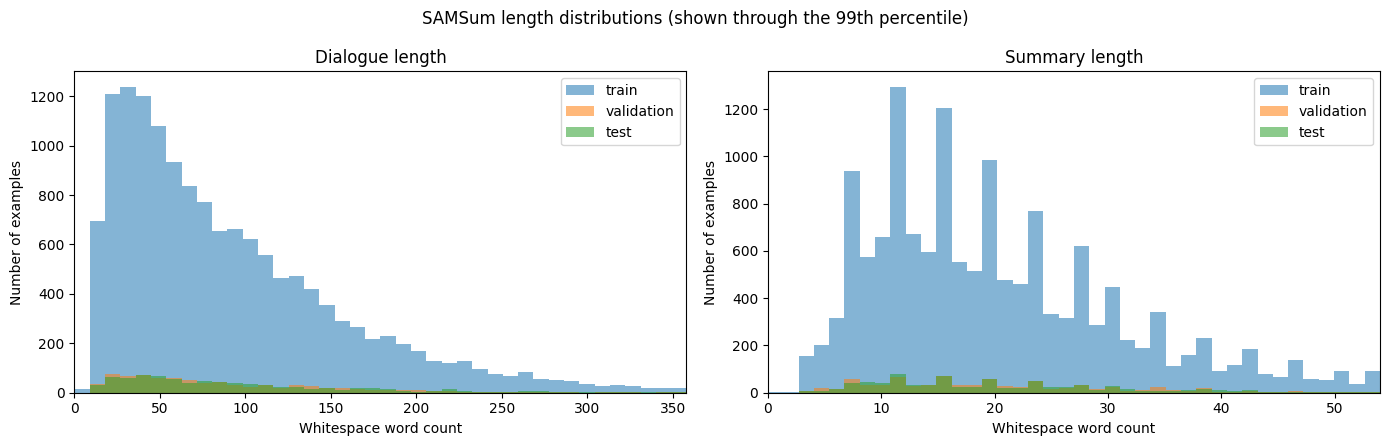

In [5]:
def percentile(values, p):
    ordered = sorted(values)
    return ordered[round((len(ordered) - 1) * p)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for axis, field, title in zip(axes, ['dialogue', 'summary'], ['Dialogue length', 'Summary length']):
    upper = max(percentile(lengths[split][field], 0.99) for split in dataset)
    for split_name in dataset:
        axis.hist(lengths[split_name][field], bins=40, range=(0, upper), alpha=0.55, label=split_name)
    axis.set(title=title, xlabel='Whitespace word count', ylabel='Number of examples', xlim=(0, upper))
    axis.legend()

fig.suptitle('SAMSum length distributions (shown through the 99th percentile)')
fig.tight_layout()
plt.show()

## Tokenizer and training-only vocabulary statistics

For the classical word-level models, text is lowercased and punctuation/symbols are retained as separate tokens. Vocabulary counts below use dialogue and summary text from **training only**; validation and test are used only to measure out-of-vocabulary (`<UNK>`) rates. Vocabulary size means the number of observed tokens retained by the threshold and excludes future special tokens such as `<PAD>`, `<UNK>`, `<SOS>`, and `<EOS>`.

In [6]:
from collections import Counter

from src.data import tokenize

sample = "Hi, Sam! I'll be there at 7:30 :)"
print(sample)
print(tokenize(sample))

Hi, Sam! I'll be there at 7:30 :)
['hi', ',', 'sam', '!', 'i', "'", 'll', 'be', 'there', 'at', '7', ':', '30', ':', ')']


In [7]:
tokenized = {
    split_name: {
        'dialogue': [tokenize(text) for text in split['dialogue']],
        'summary': [tokenize(text) for text in split['summary']],
    }
    for split_name, split in dataset.items()
}

train_token_counts = Counter()
for field in ('dialogue', 'summary'):
    for tokens in tokenized['train'][field]:
        train_token_counts.update(tokens)

print(f"Unique tokens observed in train: {len(train_token_counts):,}")
print(f"Total train tokens (dialogues + summaries): {sum(train_token_counts.values()):,}")

Unique tokens observed in train: 30,460
Total train tokens (dialogues + summaries): 2,264,472


In [8]:
def unknown_rate(split_name, vocabulary):
    tokens = (
        token
        for field in ('dialogue', 'summary')
        for example in tokenized[split_name][field]
        for token in example
    )
    total = unknown = 0
    for token in tokens:
        total += 1
        unknown += token not in vocabulary
    return 100 * unknown / total

thresholds = [1, 2, 3, 5]
print(f"{'min_freq':>8}  {'vocab size':>10}  {'validation UNK %':>18}  {'test UNK %':>10}")
print('-' * 58)
for min_freq in thresholds:
    vocabulary = {token for token, count in train_token_counts.items() if count >= min_freq}
    validation_unk = unknown_rate('validation', vocabulary)
    test_unk = unknown_rate('test', vocabulary)
    print(f'{min_freq:>8}  {len(vocabulary):>10,}  {validation_unk:>17.2f}%  {test_unk:>9.2f}%')

min_freq  vocab size    validation UNK %  test UNK %
----------------------------------------------------------
       1      30,460               1.21%       1.24%
       2      20,893               1.55%       1.56%
       3      16,035               1.92%       1.87%
       5      11,970               2.45%       2.44%


## Tokenizer-based lengths and truncation rates

These lengths exclude any future start/end tokens. A sequence is counted as truncated only when its tokenized length is greater than the stated maximum.

In [9]:
token_lengths = {
    split_name: {field: [len(tokens) for tokens in examples] for field, examples in fields.items()}
    for split_name, fields in tokenized.items()
}

for split_name, fields in token_lengths.items():
    print(f'\n{split_name.upper()} (tokenizer tokens)')
    for field, values in fields.items():
        stats = describe_lengths(values)
        print(f"  {field:8} min={stats['min']:>4}  mean={stats['mean']:>6.1f}  "
              f"median={stats['median']:>4}  p95={stats['p95']:>4}  max={stats['max']:>4}")


TRAIN (tokenizer tokens)
  dialogue min=  10  mean= 129.5  median= 102  p95= 324  max=1047
  summary  min=   1  mean=  24.2  median=  21  p95=  51  max=  77

VALIDATION (tokenizer tokens)
  dialogue min=  15  mean= 126.3  median=  98  p95= 303  max= 693
  summary  min=   4  mean=  24.2  median=  21  p95=  51  max=  70

TEST (tokenizer tokens)
  dialogue min=  14  mean= 132.1  median= 102  p95= 339  max= 681
  summary  min=   4  mean=  23.9  median=  22  p95=  49  max=  77


In [10]:
def truncation_rate(lengths, maximum):
    return 100 * sum(length > maximum for length in lengths) / len(lengths)

def print_truncation_table(field, maximums):
    print(f'\n{field.title()} truncation rate (%)')
    print(f"{'max tokens':>10}  {'train':>8}  {'validation':>11}  {'test':>8}")
    print('-' * 44)
    for maximum in maximums:
        rates = [truncation_rate(token_lengths[split][field], maximum) for split in ('train', 'validation', 'test')]
        print(f'{maximum:>10}  {rates[0]:>7.2f}%  {rates[1]:>10.2f}%  {rates[2]:>7.2f}%')

print_truncation_table('dialogue', [200, 250, 300])
print_truncation_table('summary', [40, 50, 60])


Dialogue truncation rate (%)
max tokens     train   validation      test
--------------------------------------------
       200    19.06%       17.73%    19.66%
       250    11.16%       10.15%    11.84%
       300     6.45%        5.26%     7.57%

Summary truncation rate (%)
max tokens     train   validation      test
--------------------------------------------
        40    12.41%       12.47%    11.72%
        50     5.20%        5.13%     4.27%
        60     1.64%        1.47%     1.34%


In [11]:
from src.data import load_samsum
from src.preprocessing import (
    build_samsum_vocabulary,
    SAMSumDataset,
    create_dataloader,
)

splits = load_samsum()
vocabulary = build_samsum_vocabulary(splits["train"])

train_dataset = SAMSumDataset(splits["train"], vocabulary)
train_loader = create_dataloader(train_dataset, batch_size=4, shuffle=True)

batch = next(iter(train_loader))

In [12]:
ids = batch["dialogue_ids"][0]

tokens = [vocabulary.itos[i.item()] for i in ids]

print(tokens)

['<SOS>', 'kate', ':', 'they', 'what', '?', 'they', 'split', 'up', '?', 'jennifer', ':', 'omg', 'why', '?', 'kate', ':', 'aamof', 'no', 'idea', 'jennifer', ':', 'did', 'you', 'talk', 'to', 'her', '?', 'kate', ':', 'not', 'yet', '.', 'how', 'is', 'she', '?', 'jennifer', ':', 'not', 'good', 'jennifer', ':', 'gotta', 'go', 'kate', ':', 'xoxo', 'jennifer', ':', 'xoxo', '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<

In [13]:
ids = batch["summary_ids"][0]

tokens = [vocabulary.itos[i.item()] for i in ids]

print(tokens)

['<SOS>', 'jennifer', 'and', 'kate', 'found', 'out', 'that', 'the', 'split', 'up', 'with', 'him', '.', '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']


## Vanilla Seq2Seq Model Verification

This is a forward-pass smoke test only. It reuses the shared training vocabulary and `train_loader` created above; no loss, optimization, training, evaluation, or decoding strategy is involved.

In [14]:
import torch

from src.models import Decoder, Encoder, Seq2Seq

encoder = Encoder(
    vocab_size=len(vocabulary),
    pad_id=vocabulary.pad_id,
    embedding_dim=256,
    hidden_dim=256,
    embedding_dropout=0.2,
)
decoder = Decoder(
    vocab_size=len(vocabulary),
    pad_id=vocabulary.pad_id,
    embedding_dim=256,
    hidden_dim=256,
    embedding_dropout=0.2,
)
model = Seq2Seq(encoder, decoder)

print(model)
trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f'\nTrainable parameters: {trainable_parameters:,}')

batch = next(iter(train_loader))
dialogue_ids = batch['dialogue_ids']
summary_ids = batch['summary_ids']
dialogue_lengths = batch['dialogue_lengths']

model.eval()
with torch.no_grad():
    encoder_hidden, encoder_cell = model.encoder(dialogue_ids, dialogue_lengths)
    output_logits = model(
        dialogue_ids,
        summary_ids,
        source_lengths=dialogue_lengths,
        teacher_forcing_ratio=0.5,
    )

print(f'\nDialogue input shape:       {tuple(dialogue_ids.shape)}')
print(f'Summary target shape:       {tuple(summary_ids.shape)}')
print(f'Model output shape:         {tuple(output_logits.shape)}')
print(f'Encoder hidden-state shape: {tuple(encoder_hidden.shape)}')
print(f'Encoder cell-state shape:   {tuple(encoder_cell.shape)}')

assert output_logits.size(-1) == len(vocabulary)
print(f'\nVerified: output vocabulary dimension ({output_logits.size(-1):,}) equals vocabulary size ({len(vocabulary):,}).')

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(20897, 256, padding_idx=0)
    (embedding_dropout): Dropout(p=0.2, inplace=False)
    (lstm): LSTM(256, 256, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(20897, 256, padding_idx=0)
    (embedding_dropout): Dropout(p=0.2, inplace=False)
    (lstm): LSTM(256, 256, batch_first=True)
    (output_projection): Linear(in_features=256, out_features=20897, bias=True)
  )
)

Trainable parameters: 17,122,465

Dialogue input shape:       (4, 178)
Summary target shape:       (4, 41)
Model output shape:         (4, 40, 20897)
Encoder hidden-state shape: (1, 4, 256)
Encoder cell-state shape:   (1, 4, 256)

Verified: output vocabulary dimension (20,897) equals vocabulary size (20,897).


For this batch, `dialogue_ids` has shape `(batch, longest_dialogue)` and `summary_ids` has shape `(batch, longest_summary)`; both include boundary tokens and may include right padding. The encoder states have shape `(layers, batch, hidden_size)`, which is `(1, batch, 256)` here. `output_logits` has shape `(batch, longest_summary - 1, vocabulary_size)`: position zero predicts the token after `<SOS>`, so its time dimension aligns with `summary_ids[:, 1:]`. Each final-dimension value is an unnormalized score for one vocabulary token.

## Vanilla Seq2Seq Training

This section first runs one optimization-step sanity check on a disposable copy of the model. Only after that cell succeeds should the full training cell be run. The experiment uses validation loss for checkpointing and early stopping; it does not evaluate on the test set.

In [15]:
import copy
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn

from src.models import Decoder, Encoder, Seq2Seq
from src.preprocessing import SAMSumDataset, create_dataloader
from src.train import (
    EARLY_STOPPING_PATIENCE,
    LEARNING_RATE,
    MAX_EPOCHS,
    MAX_GRAD_NORM,
    SEED,
    TRAIN_TEACHER_FORCING_RATIO,
    fit,
    get_device,
    set_seed,
    training_sanity_check,
)

set_seed(SEED)
device = get_device()
print(f'Using device: {device}')

train_dataset = SAMSumDataset(splits['train'], vocabulary)
validation_dataset = SAMSumDataset(splits['validation'], vocabulary)
train_loader = create_dataloader(train_dataset, batch_size=32, shuffle=True)
validation_loader = create_dataloader(validation_dataset, batch_size=32, shuffle=False)

def make_vanilla_model():
    encoder = Encoder(len(vocabulary), vocabulary.pad_id, 256, 256, 0.2)
    decoder = Decoder(len(vocabulary), vocabulary.pad_id, 256, 256, 0.2)
    return Seq2Seq(encoder, decoder)

model = make_vanilla_model().to(device)
criterion = nn.CrossEntropyLoss(ignore_index=vocabulary.pad_id)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
checkpoint_path = Path('checkpoints/vanilla_seq2seq_best.pt')

print(f'Vocabulary size: {len(vocabulary):,}')
print(f'Batch size: 32 | Learning rate: {LEARNING_RATE} | PAD index: {vocabulary.pad_id}')

Using device: cuda
Vocabulary size: 20,897
Batch size: 32 | Learning rate: 0.001 | PAD index: 0


In [16]:
# This copy is intentionally discarded after confirming a complete update works.
sanity_model = copy.deepcopy(model)
sanity_optimizer = torch.optim.Adam(sanity_model.parameters(), lr=LEARNING_RATE)
sanity_batch = next(iter(train_loader))
sanity_loss, preclip_gradient_norm = training_sanity_check(
    sanity_model,
    sanity_batch,
    sanity_optimizer,
    criterion,
    device,
    teacher_forcing_ratio=TRAIN_TEACHER_FORCING_RATIO,
    max_grad_norm=MAX_GRAD_NORM,
)
print(f'One-batch sanity check passed. Loss: {sanity_loss:.4f}')
print(f'Gradient norm before clipping: {preclip_gradient_norm:.4f}; clipping maximum: {MAX_GRAD_NORM}')

C:\Users\Omar\Desktop\NN Project\.venv\lib\site-packages\torch\nn\modules\rnn.py:1177: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  result = _VF.lstm(
C:\Users\Omar\Desktop\NN Project\.venv\lib\site-packages\torch\nn\modules\rnn.py:1164: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  result = _VF.lstm(


One-batch sanity check passed. Loss: 9.9535
Gradient norm before clipping: 0.2043; clipping maximum: 1.0


In [17]:
# Run after the sanity-check cell has completed successfully.
# Resetting the seed makes the full run reproducible independently of the smoke test.
set_seed(SEED)
history = fit(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    optimizer=optimizer,
    criterion=criterion,
    checkpoint_path=checkpoint_path,
    device=device,
    max_epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
    teacher_forcing_ratio=TRAIN_TEACHER_FORCING_RATIO,
)

print(
    f'Best validation checkpoint: epoch {history.best_epoch} '
    f'(loss={history.best_validation_loss:.4f}) at {checkpoint_path}'
)

Epoch 01 | train loss: 6.1681 | validation loss: 6.1267
Epoch 02 | train loss: 5.6223 | validation loss: 6.1265
Epoch 03 | train loss: 5.4739 | validation loss: 6.1166
Epoch 04 | train loss: 5.3927 | validation loss: 6.1063
Epoch 05 | train loss: 5.2993 | validation loss: 6.1819
Epoch 06 | train loss: 5.2290 | validation loss: 6.1225
Epoch 07 | train loss: 5.1381 | validation loss: 6.1212
Early stopping after 7 epochs (patience=3).
Best validation checkpoint: epoch 4 (loss=6.1063) at checkpoints\vanilla_seq2seq_best.pt


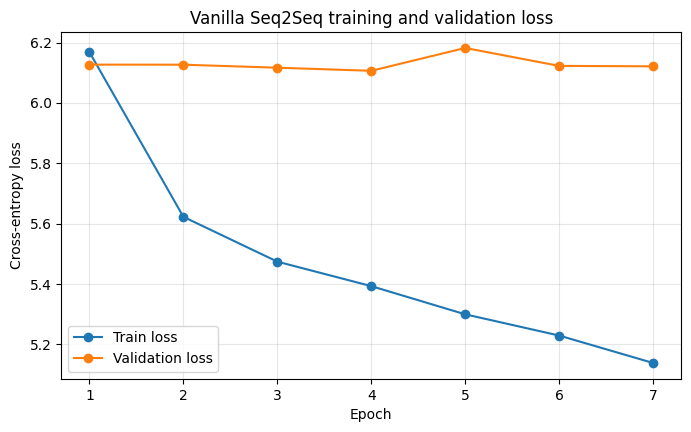

In [20]:
epochs = range(1, len(history.train_losses) + 1)
plt.figure(figsize=(8, 4.5))
plt.plot(epochs, history.train_losses, marker='o', label='Train loss')
plt.plot(epochs, history.validation_losses, marker='o', label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('Vanilla Seq2Seq training and validation loss')
plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Vanilla Seq2Seq Evaluation

This section is **validation-only**. It loads the checkpoint selected by validation loss and does not load, inspect, iterate over, or generate predictions from the test split. Greedy decoding begins with `<SOS>`, feeds each argmax token into the next decoder step, and stops at `<EOS>` or 50 generated content tokens.

In [21]:
from src.evaluate import (
    DEFAULT_MAX_GENERATION_LENGTH,
    evaluate_validation,
    save_validation_evaluation,
)

if not checkpoint_path.is_file():
    raise FileNotFoundError(
        f'Best validation checkpoint not found: {checkpoint_path}. '
        'Run the Vanilla Seq2Seq Training section first.'
    )

# Create a fresh model, then restore only the validation-selected checkpoint.
evaluation_model = make_vanilla_model().to(device)
checkpoint = torch.load(checkpoint_path, map_location=device)
evaluation_model.load_state_dict(checkpoint['model_state_dict'])

validation_evaluation = evaluate_validation(
    model=evaluation_model,
    validation_loader=validation_loader,
    vocabulary=vocabulary,
    device=device,
    max_generation_length=DEFAULT_MAX_GENERATION_LENGTH,
)
predictions_path, metrics_path = save_validation_evaluation(
    validation_evaluation,
    Path('results/vanilla_seq2seq_validation'),
)

print(f"Checkpoint epoch: {checkpoint['epoch']} | validation loss: {checkpoint['validation_loss']:.4f}")
for name, value in validation_evaluation.metrics.items():
    print(f'{name}: {value:.4f}')
print(f'\nSaved validation predictions: {predictions_path}')
print(f'Saved validation metrics: {metrics_path}')

Checkpoint epoch: 4 | validation loss: 6.1063
rouge_1: 0.1484
rouge_2: 0.0091
rouge_l: 0.1295
generated_length_mean: 13.1968
generated_length_median: 11.0000
reference_length_mean: 23.8154
reference_length_median: 21.0000
generated_eos_percent: 100.0000
hit_max_generation_length_percent: 0.0000

Saved validation predictions: results\vanilla_seq2seq_validation\predictions.jsonl
Saved validation metrics: results\vanilla_seq2seq_validation\metrics.json


In [22]:
# Five ordinary examples plus five of the longest validation dialogues.
ordinary_examples = validation_evaluation.predictions[:5]
long_dialogue_examples = sorted(
    validation_evaluation.predictions,
    key=lambda record: record['dialogue_length'],
    reverse=True,
)

example_records = []
seen_ids = set()
for record in ordinary_examples + long_dialogue_examples:
    if record['id'] not in seen_ids:
        example_records.append(record)
        seen_ids.add(record['id'])
    if len(example_records) == 10:
        break

for number, record in enumerate(example_records, start=1):
    print(f"{'=' * 100}\nExample {number} | dialogue tokens: {record['dialogue_length']}")
    print(f"Dialogue:\n{record['dialogue']}")
    print(f"\nReference summary:\n{record['reference_summary']}")
    print(f"\nGenerated summary:\n{record['generated_summary']}")
    print(
        f"EOS generated: {record['generated_eos']} | "
        f"hit max length: {record['hit_max_generation_length']} | "
        f"generated/reference lengths: {record['generated_length']}/{record['reference_length']}"
    )

Example 1 | dialogue tokens: 247
Dialogue:
A: Hi Tom, are you busy tomorrow’s afternoon?
B: I’m pretty sure I am. What’s up?
A: Can you go with me to the animal shelter?.
B: What do you want to do?
A: I want to get a puppy for my son.
B: That will make him so happy.
A: Yeah, we’ve discussed it many times. I think he’s ready now.
B: That’s good. Raising a dog is a tough issue. Like having a baby ;-) 
A: I'll get him one of those little dogs.
B: One that won't grow up too big;-)
A: And eat too much;-))
B: Do you know which one he would like?
A: Oh, yes, I took him there last Monday. He showed me one that he really liked.
B: I bet you had to drag him away.
A: He wanted to take it home right away ;-).
B: I wonder what he'll name it.
A: He said he’d name it after his dead hamster – Lemmy  - he's  a great Motorhead fan :-)))

Reference summary:
A will go to the animal shelter tomorrow to get a puppy for her son. They already visited the shelter last Monday and the son chose the puppy. 

Gene

## Tiny Training-Subset Overfitting Diagnostic

This is a debugging-only memorization test. It uses exactly the first 32 examples of `train_dataset`, a fresh copy of the unchanged vanilla model, and full teacher forcing. It does not read from validation or test data and must not be reported as a model result.

In [ ]:
from functools import partial

from torch.utils.data import DataLoader, Subset

from src.diagnostics import run_tiny_subset_overfit
from src.preprocessing import collate_samsum

set_seed(SEED)
tiny_subset_indices = list(range(32))
tiny_train_subset = Subset(train_dataset, tiny_subset_indices)
tiny_subset_loader = DataLoader(
    tiny_train_subset,
    batch_size=32,
    shuffle=True,
    collate_fn=partial(collate_samsum, pad_id=vocabulary.pad_id),
)

diagnostic_model = make_vanilla_model().to(device)
diagnostic_optimizer = torch.optim.Adam(diagnostic_model.parameters(), lr=LEARNING_RATE)
diagnostic_criterion = nn.CrossEntropyLoss(ignore_index=vocabulary.pad_id)
tiny_diagnostic = run_tiny_subset_overfit(
    model=diagnostic_model,
    train_subset_loader=tiny_subset_loader,
    optimizer=diagnostic_optimizer,
    criterion=diagnostic_criterion,
    vocabulary=vocabulary,
    device=device,
    epochs=200,
    snapshot_every=25,
    max_generation_length=50,
)

for epoch in [1, 25, 50, 75, 100, 125, 150, 175, 200]:
    print(f'Epoch {epoch:03d} training loss: {tiny_diagnostic.losses[epoch - 1]:.4f}')

In [ ]:
plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(tiny_diagnostic.losses) + 1), tiny_diagnostic.losses)
plt.xlabel('Diagnostic epoch')
plt.ylabel('Training cross-entropy loss')
plt.title('32-example training-only overfitting diagnostic')
plt.grid(alpha=0.3)
plt.show()

final_snapshot = tiny_diagnostic.snapshots[200]
raw_train_examples = {str(train_dataset.split[index]['id']): train_dataset.split[index] for index in tiny_subset_indices}
for number, record in enumerate(final_snapshot[:5], start=1):
    raw_example = raw_train_examples[record['id']]
    print(f"{'=' * 90}\nTraining example {number}")
    print(f"Dialogue:\n{raw_example['dialogue']}")
    print(f"\nReference summary:\n{raw_example['summary']}")
    print(f"\nGreedy generated summary:\n{record['generated_summary']}")
    print(f"EOS generated: {record['generated_eos']} | hit max length: {record['hit_max_generation_length']}")

print(f'Final teacher-forced training loss: {tiny_diagnostic.losses[-1]:.4f}')
print('Interpret this with the displayed greedy generations: low loss plus substantially example-specific generations supports a functioning implementation.')

## Controlled Vanilla Seq2Seq Experiment — Teacher Forcing 1.0

This is a separate full-data vanilla run. Architecture, preprocessing, batch size, optimizer, learning rate, clipping, seed, epochs, and patience match the first run. Both training and checkpoint-selection validation cross-entropy use teacher forcing ratio 1.0. Greedy decoding remains validation-only and uses no teacher forcing.

In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
from datasets import load_dataset
from torch import nn

from src.models import Decoder, Encoder, Seq2Seq
from src.preprocessing import SAMSumDataset, build_samsum_vocabulary, create_dataloader
from src.train import (
    EARLY_STOPPING_PATIENCE,
    LEARNING_RATE,
    MAX_EPOCHS,
    SEED,
    fit,
    get_device,
    set_seed,
)

set_seed(SEED)
device = get_device()
# Intentionally load only the train and validation splits for this experiment.
train_split = load_dataset('knkarthick/samsum', split='train')
validation_split = load_dataset('knkarthick/samsum', split='validation')
vocabulary = build_samsum_vocabulary(train_split)
train_loader = create_dataloader(SAMSumDataset(train_split, vocabulary), batch_size=32, shuffle=True)
validation_loader = create_dataloader(SAMSumDataset(validation_split, vocabulary), batch_size=32, shuffle=False)

def make_tf1_model():
    encoder = Encoder(len(vocabulary), vocabulary.pad_id, 256, 256, 0.2)
    decoder = Decoder(len(vocabulary), vocabulary.pad_id, 256, 256, 0.2)
    return Seq2Seq(encoder, decoder)

tf1_model = make_tf1_model().to(device)
tf1_optimizer = torch.optim.Adam(tf1_model.parameters(), lr=LEARNING_RATE)
tf1_criterion = nn.CrossEntropyLoss(ignore_index=vocabulary.pad_id)
tf1_checkpoint_path = Path('checkpoints/vanilla_seq2seq_tf1_best.pt')

tf1_history = fit(
    model=tf1_model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    optimizer=tf1_optimizer,
    criterion=tf1_criterion,
    checkpoint_path=tf1_checkpoint_path,
    device=device,
    max_epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
    teacher_forcing_ratio=1.0,
    validation_teacher_forcing_ratio=1.0,
)

print(
    f'Best teacher-forced validation checkpoint: epoch {tf1_history.best_epoch} '
    f'(loss={tf1_history.best_validation_loss:.4f}) at {tf1_checkpoint_path}'
)

C:\Users\Omar\Desktop\NN Project\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 01 | train loss: 5.5915 | validation loss: 4.8548
Epoch 02 | train loss: 4.7470 | validation loss: 4.6246
Epoch 03 | train loss: 4.4844 | validation loss: 4.5218
Epoch 04 | train loss: 4.2952 | validation loss: 4.4567
Epoch 05 | train loss: 4.1369 | validation loss: 4.4250
Epoch 06 | train loss: 3.9962 | validation loss: 4.4082
Epoch 07 | train loss: 3.8657 | validation loss: 4.4025
Epoch 08 | train loss: 3.7454 | validation loss: 4.4059
Epoch 09 | train loss: 3.6342 | validation loss: 4.4118
Epoch 10 | train loss: 3.5287 | validation loss: 4.4349
Early stopping after 10 epochs (patience=3).
Best teacher-forced validation checkpoint: epoch 7 (loss=4.4025) at checkpoints\vanilla_seq2seq_tf1_best.pt


In [7]:
from src.evaluate import evaluate_validation, save_validation_evaluation

if not tf1_checkpoint_path.is_file():
    raise FileNotFoundError(f'Checkpoint not found: {tf1_checkpoint_path}')

tf1_evaluation_model = make_tf1_model().to(device)
tf1_checkpoint = torch.load(tf1_checkpoint_path, map_location=device)
tf1_evaluation_model.load_state_dict(tf1_checkpoint['model_state_dict'])
tf1_validation_evaluation = evaluate_validation(
    model=tf1_evaluation_model,
    validation_loader=validation_loader,
    vocabulary=vocabulary,
    device=device,
    max_generation_length=50,
)
tf1_predictions_path, tf1_metrics_path = save_validation_evaluation(
    tf1_validation_evaluation,
    Path('results/vanilla_seq2seq_tf1_validation'),
)

print(f"Checkpoint epoch: {tf1_checkpoint['epoch']} | teacher-forced validation loss: {tf1_checkpoint['validation_loss']:.4f}")
for name, value in tf1_validation_evaluation.metrics.items():
    print(f'{name}: {value:.4f}')
print(f'\nSaved validation predictions: {tf1_predictions_path}')
print(f'Saved validation metrics: {tf1_metrics_path}')

Checkpoint epoch: 7 | teacher-forced validation loss: 4.4025
rouge_1: 0.1321
rouge_2: 0.0143
rouge_l: 0.1151
generated_length_mean: 13.1773
generated_length_median: 12.0000
reference_length_mean: 23.8154
reference_length_median: 21.0000
generated_eos_percent: 99.6333
hit_max_generation_length_percent: 0.3667

Saved validation predictions: results\vanilla_seq2seq_tf1_validation\predictions.jsonl
Saved validation metrics: results\vanilla_seq2seq_tf1_validation\metrics.json


In [6]:
for number, record in enumerate(tf1_validation_evaluation.predictions[:5], start=1):
    print(f"{'=' * 90}\nValidation example {number}")
    print(f"Dialogue:\n{record['dialogue']}")
    print(f"\nReference summary:\n{record['reference_summary']}")
    print(f"\nGreedy generated summary:\n{record['generated_summary']}")
    print(f"EOS generated: {record['generated_eos']} | hit max length: {record['hit_max_generation_length']}")

Validation example 1
Dialogue:
A: Hi Tom, are you busy tomorrow’s afternoon?
B: I’m pretty sure I am. What’s up?
A: Can you go with me to the animal shelter?.
B: What do you want to do?
A: I want to get a puppy for my son.
B: That will make him so happy.
A: Yeah, we’ve discussed it many times. I think he’s ready now.
B: That’s good. Raising a dog is a tough issue. Like having a baby ;-) 
A: I'll get him one of those little dogs.
B: One that won't grow up too big;-)
A: And eat too much;-))
B: Do you know which one he would like?
A: Oh, yes, I took him there last Monday. He showed me one that he really liked.
B: I bet you had to drag him away.
A: He wanted to take it home right away ;-).
B: I wonder what he'll name it.
A: He said he’d name it after his dead hamster – Lemmy  - he's  a great Motorhead fan :-)))

Reference summary:
A will go to the animal shelter tomorrow to get a puppy for her son. They already visited the shelter last Monday and the son chose the puppy. 

Greedy generated

In [ ]:
epochs = range(1, len(history.train_losses) + 1)
plt.figure(figsize=(8, 4.5))
plt.plot(epochs, history.train_losses, marker='o', label='Train loss')
plt.plot(epochs, history.validation_losses, marker='o', label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('Vanilla Seq2Seq training and validation loss')
plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

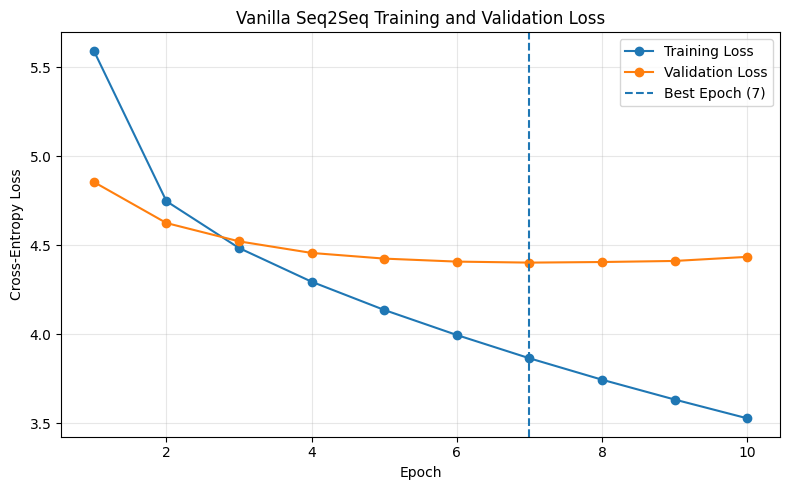

In [9]:
import matplotlib.pyplot as plt

epochs = range(1, len(tf1_history.train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    tf1_history.train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    tf1_history.validation_losses,
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    x=tf1_history.best_epoch,
    linestyle="--",
    label=f"Best Epoch ({tf1_history.best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Vanilla Seq2Seq Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Bahdanau Attention Model Verification

This self-contained smoke test loads **only the training split** to rebuild the vocabulary and obtain one batch. It verifies tensor layouts, masking, gradients, and parameter counts; it does not train or evaluate either model.

In [ ]:
# This cell is independent of every earlier notebook section.
from pathlib import Path
import sys

import torch
from torch import nn
from datasets import load_dataset

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.attention import AttentionDecoder, AttentionEncoder, AttentionSeq2Seq
from src.models import Decoder, EMBEDDING_DIM, EMBEDDING_DROPOUT, Encoder, HIDDEN_DIM, Seq2Seq
from src.preprocessing import SAMSumDataset, build_samsum_vocabulary, create_dataloader
from src.train import SEED, get_device, set_seed

set_seed(SEED)
device = get_device()

# Deliberately request only `train`: no validation or test split is loaded.
verification_train_split = load_dataset('knkarthick/samsum', split='train')
verification_vocabulary = build_samsum_vocabulary(verification_train_split)
verification_dataset = SAMSumDataset(verification_train_split, verification_vocabulary)
verification_loader = create_dataloader(verification_dataset, batch_size=32, shuffle=False)
verification_batch = next(iter(verification_loader))

source_ids = verification_batch['dialogue_ids'].to(device)
target_ids = verification_batch['summary_ids'].to(device)
source_lengths = verification_batch['dialogue_lengths'].to(device)
vocab_size = len(verification_vocabulary)
pad_id = verification_vocabulary.pad_id

attention_model = AttentionSeq2Seq(
    AttentionEncoder(vocab_size, pad_id, EMBEDDING_DIM, HIDDEN_DIM, EMBEDDING_DROPOUT),
    AttentionDecoder(vocab_size, pad_id, EMBEDDING_DIM, HIDDEN_DIM, HIDDEN_DIM, EMBEDDING_DROPOUT),
).to(device)
vanilla_model = Seq2Seq(
    Encoder(vocab_size, pad_id, EMBEDDING_DIM, HIDDEN_DIM, EMBEDDING_DROPOUT),
    Decoder(vocab_size, pad_id, EMBEDDING_DIM, HIDDEN_DIM, EMBEDDING_DROPOUT),
).to(device)

attention_model.train()
encoder_outputs, encoder_hidden, encoder_cell = attention_model.encoder(source_ids, source_lengths)
logits, attention_weights = attention_model(
    source_ids,
    target_ids,
    source_lengths=source_lengths,
    teacher_forcing_ratio=1.0,
    return_attention=True,
)

# Weights are (batch, target steps, source steps). The source mask is true only
# at original, unpadded dialogue positions.
source_positions = torch.arange(source_ids.size(1), device=device).unsqueeze(0)
source_mask = source_positions < source_lengths.unsqueeze(1)
valid_weight_sums = attention_weights.masked_fill(~source_mask.unsqueeze(1), 0.0).sum(dim=-1)
padded_weights = attention_weights.masked_select((~source_mask).unsqueeze(1).expand_as(attention_weights))
max_attention_sum_error = (valid_weight_sums - 1.0).abs().max().item()
max_padded_attention = padded_weights.abs().max().item() if padded_weights.numel() else 0.0

criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
loss = criterion(logits.reshape(-1, logits.size(-1)), target_ids[:, 1:].reshape(-1))
attention_model.zero_grad(set_to_none=True)
loss.backward()
has_gradients = any(parameter.grad is not None for parameter in attention_model.parameters())

assert logits.shape == (source_ids.size(0), target_ids.size(1) - 1, vocab_size)
assert attention_weights.shape == (source_ids.size(0), target_ids.size(1) - 1, source_ids.size(1))
assert max_attention_sum_error < 1e-5
assert max_padded_attention < 1e-7
assert has_gradients

count_trainable = lambda model: sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f'Device:                         {device}')
print(f'Dialogue IDs:                   {tuple(source_ids.shape)}  = (batch, padded source tokens)')
print(f'Dialogue lengths:               {tuple(source_lengths.shape)}  = (batch,)')
print(f'Summary IDs:                    {tuple(target_ids.shape)}  = (batch, padded target tokens including <SOS>)')
print(f'Encoder outputs:                 {tuple(encoder_outputs.shape)}  = (batch, padded source tokens, hidden)')
print(f'Encoder hidden/cell:             {tuple(encoder_hidden.shape)} / {tuple(encoder_cell.shape)}  = (layers, batch, hidden)')
print(f'Decoder logits:                  {tuple(logits.shape)}  = (batch, target tokens after <SOS>, vocabulary)')
print(f'Attention weights:               {tuple(attention_weights.shape)}  = (batch, target tokens after <SOS>, source tokens)')
print(f'Max valid-position sum error:    {max_attention_sum_error:.2e}')
print(f'Max padded-position attention:   {max_padded_attention:.2e}')
print(f'Forward/backward loss:           {loss.item():.4f}; gradients present: {has_gradients}')
print(f'Vanilla trainable parameters:    {count_trainable(vanilla_model):,}')
print(f'Attention trainable parameters:  {count_trainable(attention_model):,}')

## Bahdanau Attention Seq2Seq: diagnostic, training, and validation evaluation

This self-contained section runs the training-only 32-example diagnostic, then the controlled full experiment. It explicitly loads only SAMSum's training and validation splits. It saves attention artifacts separately, performs greedy generation only on validation data, and never loads the test split.

In [11]:
# Independent of all preceding notebook sections.
from pathlib import Path
import sys
import json

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# The runner uses only `split='train'` and `split='validation'`. It first
# performs the same first-32-training-example diagnostic, resets seed 6,
# trains with teacher forcing 1.0 for both train/validation CE, saves the
# best checkpoint, and then greedily evaluates that checkpoint on validation.
from scripts.run_attention_experiment import (
    HISTORY_PATH,
    LOSS_PLOT_PATH,
    RESULTS_DIRECTORY,
    main as run_attention_experiment,
)

run_attention_experiment()

with HISTORY_PATH.open(encoding='utf-8') as history_file:
    attention_history = json.load(history_file)
with (RESULTS_DIRECTORY / 'metrics.json').open(encoding='utf-8') as metrics_file:
    attention_metrics = json.load(metrics_file)

print('\nBest epoch:', attention_history['best_epoch'])
print('Best teacher-forced validation loss:', f"{attention_history['best_validation_loss']:.4f}")
for name, value in attention_metrics.items():
    print(f'{name}: {value:.4f}')

# Display the saved loss plot in the notebook after the run.
from IPython.display import Image, display
display(Image(filename=str(LOSS_PLOT_PATH)))

Device: cuda
Diagnostic epoch 001 | training loss: 9.9529
Diagnostic epoch 025 | training loss: 4.5850
Diagnostic epoch 050 | training loss: 3.2788
Diagnostic epoch 075 | training loss: 1.8348
Diagnostic epoch 100 | training loss: 0.7976


KeyboardInterrupt: 

In [10]:
from pathlib import Path
import json

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
PREDICTIONS_PATH = PROJECT_ROOT / 'results' / 'attention_seq2seq_tf1_validation' / 'predictions.jsonl'

highlighted_vanilla_ids = [
    '13817023', '13716628', '13829420', '13819648', '13728448',
    '13727903', '13821290', '13717185', '13862374', '13817283',
]
with PREDICTIONS_PATH.open(encoding='utf-8') as predictions_file:
    attention_predictions_by_id = {record['id']: record for record in map(json.loads, predictions_file)}

for number, example_id in enumerate(highlighted_vanilla_ids, start=1):
    record = attention_predictions_by_id[example_id]
    print(f"{'=' * 100}\nExample {number} | validation ID: {example_id} | dialogue tokens: {record['dialogue_length']}")
    print(f"Dialogue:\n{record['dialogue']}")
    print(f"\nReference summary:\n{record['reference_summary']}")
    print(f"\nAttention greedy summary:\n{record['generated_summary']}")
    print(f"EOS generated: {record['generated_eos']} | hit maximum length: {record['hit_max_generation_length']} | generated/reference lengths: {record['generated_length']}/{record['reference_length']}")

Example 1 | validation ID: 13817023 | dialogue tokens: 247
Dialogue:
A: Hi Tom, are you busy tomorrow’s afternoon?
B: I’m pretty sure I am. What’s up?
A: Can you go with me to the animal shelter?.
B: What do you want to do?
A: I want to get a puppy for my son.
B: That will make him so happy.
A: Yeah, we’ve discussed it many times. I think he’s ready now.
B: That’s good. Raising a dog is a tough issue. Like having a baby ;-) 
A: I'll get him one of those little dogs.
B: One that won't grow up too big;-)
A: And eat too much;-))
B: Do you know which one he would like?
A: Oh, yes, I took him there last Monday. He showed me one that he really liked.
B: I bet you had to drag him away.
A: He wanted to take it home right away ;-).
B: I wonder what he'll name it.
A: He said he’d name it after his dead hamster – Lemmy  - he's  a great Motorhead fan :-)))

Reference summary:
A will go to the animal shelter tomorrow to get a puppy for her son. They already visited the shelter last Monday and the s

### Attention model training

Independent cell: trains the Bahdanau attention model with the frozen vanilla TF=1.0 protocol. It loads only the SAMSum training and validation splits and saves an attention-specific checkpoint.

In [ ]:
# Independent training cell; it does not depend on earlier notebook variables.
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from torch import nn

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.attention import AttentionDecoder, AttentionEncoder, AttentionSeq2Seq
from src.preprocessing import SAMSumDataset, build_samsum_vocabulary, create_dataloader
from src.train import EARLY_STOPPING_PATIENCE, LEARNING_RATE, MAX_EPOCHS, fit, get_device, set_seed

SEED = 6
BATCH_SIZE = 32
set_seed(SEED)
device = get_device()

# Only the train split constructs the shared vocabulary; validation is used only for validation loss.
attention_train_split = load_dataset('knkarthick/samsum', split='train')
attention_validation_split = load_dataset('knkarthick/samsum', split='validation')
attention_vocabulary = build_samsum_vocabulary(attention_train_split)
attention_train_loader = create_dataloader(
    SAMSumDataset(attention_train_split, attention_vocabulary), batch_size=BATCH_SIZE, shuffle=True
)
attention_validation_loader = create_dataloader(
    SAMSumDataset(attention_validation_split, attention_vocabulary), batch_size=BATCH_SIZE, shuffle=False
)

def make_attention_model():
    encoder = AttentionEncoder(len(attention_vocabulary), attention_vocabulary.pad_id, 256, 256, 0.2)
    decoder = AttentionDecoder(len(attention_vocabulary), attention_vocabulary.pad_id, 256, 256, 256, 0.2)
    return AttentionSeq2Seq(encoder, decoder)

attention_model = make_attention_model().to(device)
attention_optimizer = torch.optim.Adam(attention_model.parameters(), lr=LEARNING_RATE)
attention_criterion = nn.CrossEntropyLoss(ignore_index=attention_vocabulary.pad_id)
attention_checkpoint_path = PROJECT_ROOT / 'checkpoints' / 'attention_seq2seq_tf1_best.pt'

attention_history = fit(
    model=attention_model,
    train_loader=attention_train_loader,
    validation_loader=attention_validation_loader,
    optimizer=attention_optimizer,
    criterion=attention_criterion,
    checkpoint_path=attention_checkpoint_path,
    device=device,
    max_epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
    teacher_forcing_ratio=1.0,
    validation_teacher_forcing_ratio=1.0,
    max_grad_norm=1.0,
)

print(f'Best checkpoint: epoch {attention_history.best_epoch} | teacher-forced validation loss: {attention_history.best_validation_loss:.4f}')
epochs = range(1, len(attention_history.train_losses) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, attention_history.train_losses, marker='o', label='Training loss')
plt.plot(epochs, attention_history.validation_losses, marker='o', label='Teacher-forced validation loss')
plt.axvline(attention_history.best_epoch, linestyle='--', label=f'Best epoch ({attention_history.best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('Bahdanau Attention Seq2Seq training and validation loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Attention model validation evaluation

Independent cell: rebuilds the training-only vocabulary, loads the saved attention checkpoint, and performs greedy teacher-forcing-0 evaluation on validation only.

In [12]:
# Independent evaluation cell; it never loads the test split.
from pathlib import Path
import sys

import torch
from datasets import load_dataset

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.attention import AttentionDecoder, AttentionEncoder, AttentionSeq2Seq
from src.attention_evaluate import evaluate_attention_validation, save_attention_validation_evaluation
from src.preprocessing import SAMSumDataset, build_samsum_vocabulary, create_dataloader
from src.train import get_device, set_seed

set_seed(6)
device = get_device()
evaluation_train_split = load_dataset('knkarthick/samsum', split='train')
evaluation_validation_split = load_dataset('knkarthick/samsum', split='validation')
evaluation_vocabulary = build_samsum_vocabulary(evaluation_train_split)
evaluation_validation_loader = create_dataloader(
    SAMSumDataset(evaluation_validation_split, evaluation_vocabulary), batch_size=32, shuffle=False
)

evaluation_model = AttentionSeq2Seq(
    AttentionEncoder(len(evaluation_vocabulary), evaluation_vocabulary.pad_id, 256, 256, 0.2),
    AttentionDecoder(len(evaluation_vocabulary), evaluation_vocabulary.pad_id, 256, 256, 256, 0.2),
).to(device)
evaluation_checkpoint_path = PROJECT_ROOT / 'checkpoints' / 'attention_seq2seq_tf1_best.pt'
if not evaluation_checkpoint_path.is_file():
    raise FileNotFoundError(f'Missing attention checkpoint: {evaluation_checkpoint_path}')
checkpoint = torch.load(evaluation_checkpoint_path, map_location=device)
evaluation_model.load_state_dict(checkpoint['model_state_dict'])

attention_validation_evaluation = evaluate_attention_validation(
    evaluation_model, evaluation_validation_loader, evaluation_vocabulary, device, max_generation_length=50
)
attention_results_directory = PROJECT_ROOT / 'results' / 'attention_seq2seq_tf1_validation'
predictions_path, metrics_path = save_attention_validation_evaluation(
    attention_validation_evaluation, attention_results_directory
)

print(f"Checkpoint epoch: {checkpoint['epoch']} | teacher-forced validation loss: {checkpoint['validation_loss']:.4f}")
for name, value in attention_validation_evaluation.metrics.items():
    print(f'{name}: {value:.4f}')
print(f'\nSaved validation predictions: {predictions_path}')
print(f'Saved validation metrics: {metrics_path}')

Checkpoint epoch: 7 | teacher-forced validation loss: 3.9091
rouge_1: 0.2828
rouge_2: 0.0782
rouge_l: 0.2381
generated_length_mean: 15.7200
generated_length_median: 13.0000
reference_length_mean: 23.8154
reference_length_median: 21.0000
generated_eos_percent: 96.6993
hit_max_generation_length_percent: 3.3007

Saved validation predictions: C:\Users\Omar\Desktop\NN Project\results\attention_seq2seq_tf1_validation\predictions.jsonl
Saved validation metrics: C:\Users\Omar\Desktop\NN Project\results\attention_seq2seq_tf1_validation\metrics.json


## Validation beam-search decoding comparison

These self-contained cells compare existing frozen vanilla and attention checkpoints under greedy, beam-3, and beam-5 decoding. They load only train (to rebuild the vocabulary) and validation, never the test split. Beam search ranks hypotheses by `sum_log_probability / ((5 + L) / 6) ** 0.6`, where `L` excludes `<SOS>` and includes emitted `<EOS>`.

In [13]:
# Independent evaluation cell. It does not retrain either model.
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Runs greedy, beam width 3, and beam width 5 for both frozen checkpoints.
# It saves every new strategy under results/validation_decoding_comparison/.
from scripts.run_decoding_comparison import main as run_decoding_comparison
run_decoding_comparison()

Device: cuda
Vanilla | greedy | R1=0.1321 | R2=0.0143 | RL=0.1151 | decode=1.74s
Vanilla | beam-3 | R1=0.1314 | R2=0.0187 | RL=0.1085 | decode=52.53s
Vanilla | beam-5 | R1=0.1174 | R2=0.0186 | RL=0.0995 | decode=87.54s
Attention | greedy | R1=0.2828 | R2=0.0782 | RL=0.2381 | decode=3.24s
Attention | beam-3 | R1=0.2706 | R2=0.0800 | RL=0.2332 | decode=69.90s
Attention | beam-5 | R1=0.2672 | R2=0.0791 | RL=0.2318 | decode=98.45s

Model | Decoding | R1 | R2 | RL | Mean Length | EOS % | Decode Time
Vanilla | greedy | 0.1321 | 0.0143 | 0.1151 | 13.18 | 99.63 | 1.74s
Vanilla | beam-3 | 0.1314 | 0.0187 | 0.1085 | 12.63 | 99.88 | 52.53s
Vanilla | beam-5 | 0.1174 | 0.0186 | 0.0995 | 11.72 | 100.00 | 87.54s
Attention | greedy | 0.2828 | 0.0782 | 0.2381 | 15.72 | 96.70 | 3.24s
Attention | beam-3 | 0.2706 | 0.0800 | 0.2332 | 12.41 | 98.53 | 69.90s
Attention | beam-5 | 0.2672 | 0.0791 | 0.2318 | 11.63 | 98.66 | 98.45s


In [14]:
# Independent results-display cell: reads only already-saved validation comparison files.
from pathlib import Path
import json

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
COMPARISON_DIRECTORY = PROJECT_ROOT / 'results' / 'validation_decoding_comparison'
with (COMPARISON_DIRECTORY / 'comparison_metrics.json').open(encoding='utf-8') as metrics_file:
    comparison = json.load(metrics_file)

print('Model | Decoding | R1 | R2 | RL | Mean Length | Median Length | EOS % | Max Length % | Decode Time')
for row in comparison['rows']:
    print(
        f"{row['model']} | {row['decoding']} | {row['rouge_1']:.4f} | {row['rouge_2']:.4f} | "
        f"{row['rouge_l']:.4f} | {row['mean_generated_length']:.2f} | {row['median_generated_length']:.0f} | "
        f"{row['eos_percent']:.2f} | {row['hit_max_length_percent']:.2f} | {row['decoding_seconds_total']:.2f}s"
    )

with (COMPARISON_DIRECTORY / 'paired_highlighted_examples.json').open(encoding='utf-8') as examples_file:
    paired_examples = json.load(examples_file)

# Same validation IDs previously highlighted for the vanilla qualitative analysis.
for example in paired_examples[:3]:
    print(f"{'=' * 100}\nValidation ID: {example['id']}")
    print(f"Reference:\n{example['reference_summary']}")
    print(f"\nVanilla greedy:\n{example['vanilla_greedy']}")
    print(f"Vanilla beam-3:\n{example['vanilla_beam_3']}")
    print(f"Vanilla beam-5:\n{example['vanilla_beam_5']}")
    print(f"\nAttention greedy:\n{example['attention_greedy']}")
    print(f"Attention beam-3:\n{example['attention_beam_3']}")
    print(f"Attention beam-5:\n{example['attention_beam_5']}")

Model | Decoding | R1 | R2 | RL | Mean Length | Median Length | EOS % | Max Length % | Decode Time
Vanilla | greedy | 0.1321 | 0.0143 | 0.1151 | 13.18 | 12 | 99.63 | 0.37 | 1.74s
Vanilla | beam-3 | 0.1314 | 0.0187 | 0.1085 | 12.63 | 10 | 99.88 | 0.12 | 52.53s
Vanilla | beam-5 | 0.1174 | 0.0186 | 0.0995 | 11.72 | 8 | 100.00 | 0.00 | 87.54s
Attention | greedy | 0.2828 | 0.0782 | 0.2381 | 15.72 | 13 | 96.70 | 3.30 | 3.24s
Attention | beam-3 | 0.2706 | 0.0800 | 0.2332 | 12.41 | 10 | 98.53 | 1.47 | 69.90s
Attention | beam-5 | 0.2672 | 0.0791 | 0.2318 | 11.63 | 10 | 98.66 | 1.34 | 98.45s
Validation ID: 13817023
Reference:
A will go to the animal shelter tomorrow to get a puppy for her son. They already visited the shelter last Monday and the son chose the puppy. 

Vanilla greedy:
the last episode of the new year's eve is broken. she's going to be there in a few days.
Vanilla beam-3:
mike is looking for a new job. she's going to be there.
Vanilla beam-5:
mike is looking for a new job. she's n

## Final validation analysis: dialogue length, qualitative material, and attention maps

These independent cells use only frozen checkpoints plus train/validation data. Training-derived tercile boundaries are fixed before validation is grouped; no test split is loaded or evaluated.

In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Uses train only to rebuild the vocabulary and freeze source-length terciles;
# uses validation predictions/checkpoint for every reported analysis.
from scripts.run_validation_analysis import main as run_validation_analysis
run_validation_analysis()

Training-derived boundaries: short <= 71; medium <= 149; long > 149

Length group | n | mean source length | Vanilla R1/R2/RL | Attention R1/R2/RL
short | 291 | 46.58 | 0.1163/0.0108/0.1062 | 0.3184/0.0959/0.2823
medium | 262 | 105.41 | 0.1336/0.0166/0.1176 | 0.2689/0.0769/0.2265
long | 265 | 221.66 | 0.1465/0.0156/0.1210 | 0.2569/0.0598/0.1998

Saved ROUGE-L plot: C:\Users\Omar\Desktop\NN Project\results\validation_analysis\figures\rouge_l_by_length_group.png
Saved attention heatmaps: 3 in C:\Users\Omar\Desktop\NN Project\results\validation_analysis\figures
Saved final validation summary: C:\Users\Omar\Desktop\NN Project\results\validation_analysis\final_validation_summary.json


Fixed training-derived stored-source boundaries: short <= 71; medium <= 149; long > 149

Group | n | Mean source length | Vanilla R1/R2/RL | Attention R1/R2/RL
short | 291 | 46.58 | 0.1163/0.0108/0.1062 | 0.3184/0.0959/0.2823
medium | 262 | 105.41 | 0.1336/0.0166/0.1176 | 0.2689/0.0769/0.2265
long | 265 | 221.66 | 0.1465/0.0156/0.1210 | 0.2569/0.0598/0.1998


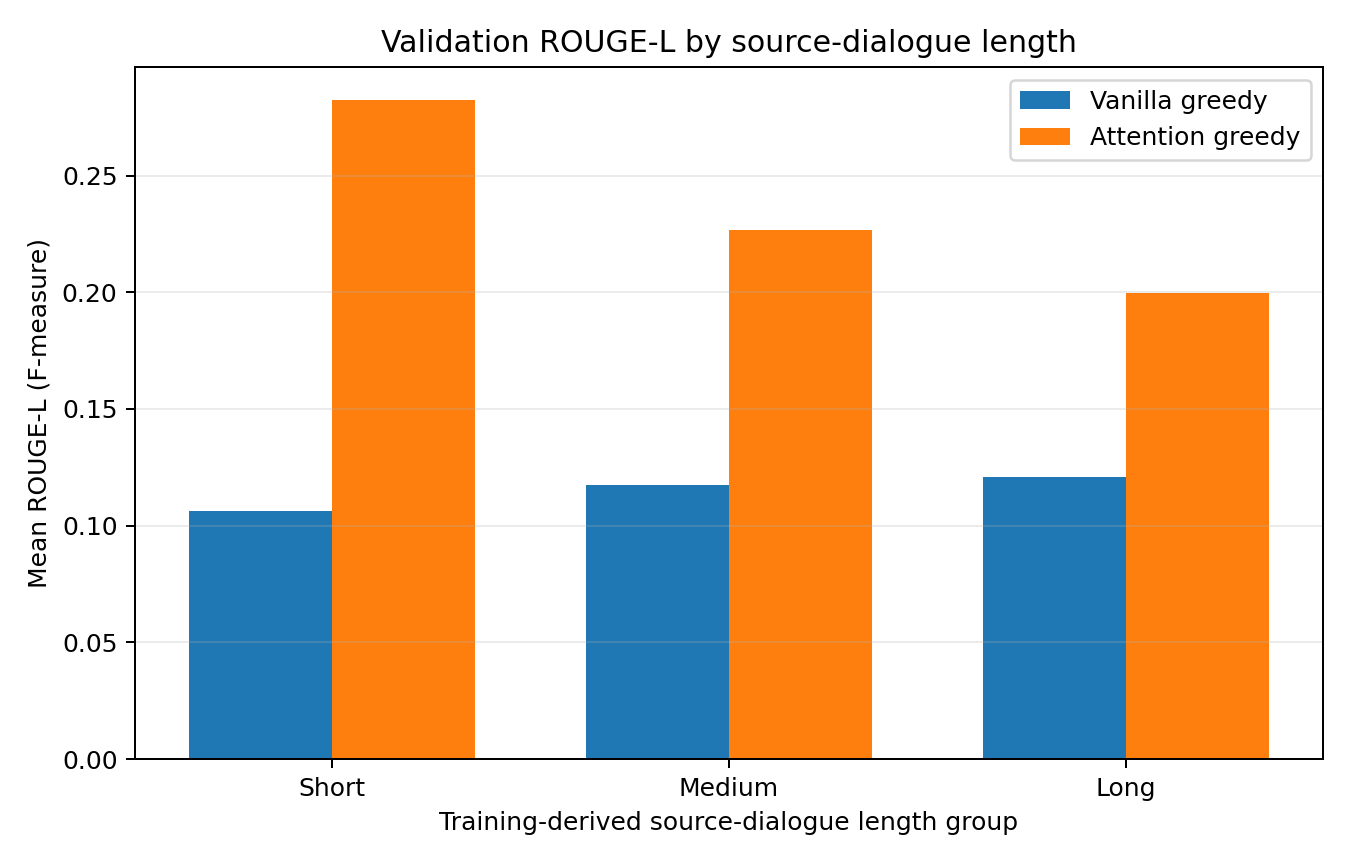


Attention map | validation ID 13731412 | short | generated: the weather is ready for christmas.


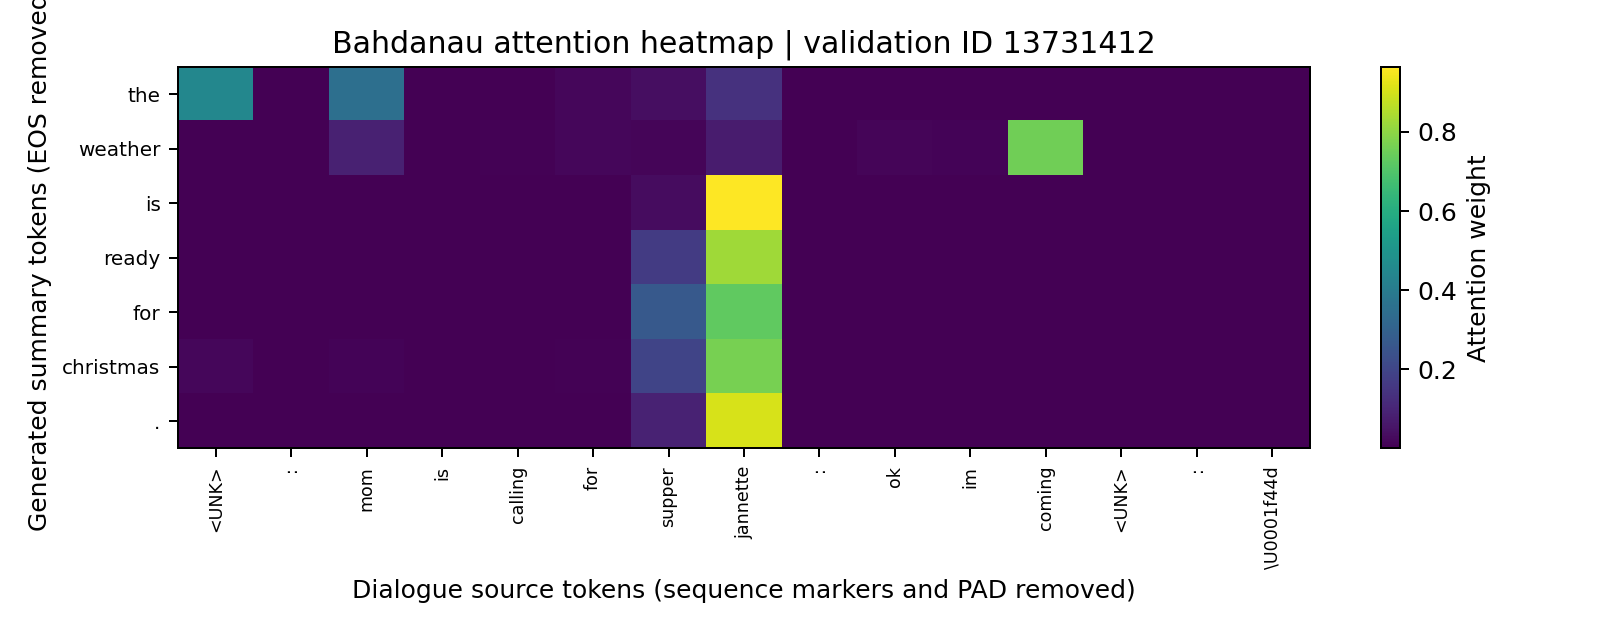


Attention map | validation ID 13862235 | medium | generated: bella and james are going to meet at the new place.


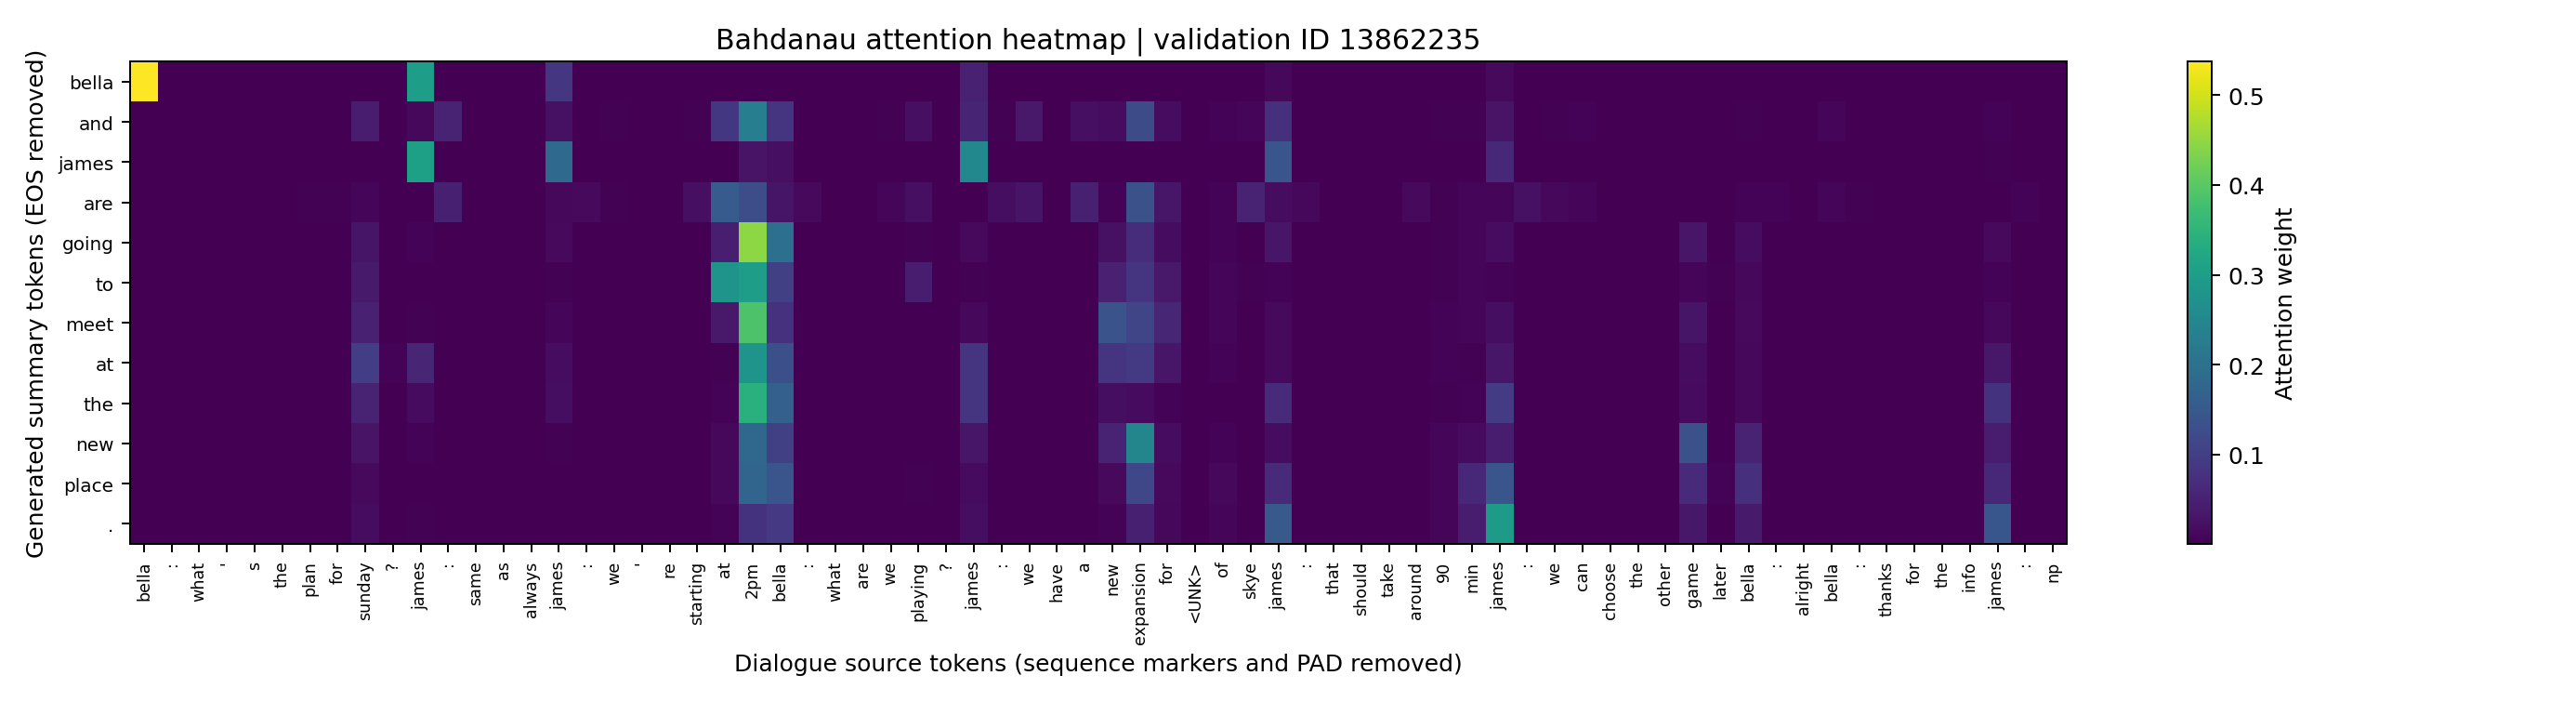


Attention map | validation ID 13681310 | short | generated: diana's brother has been hacked since he's not getting better.


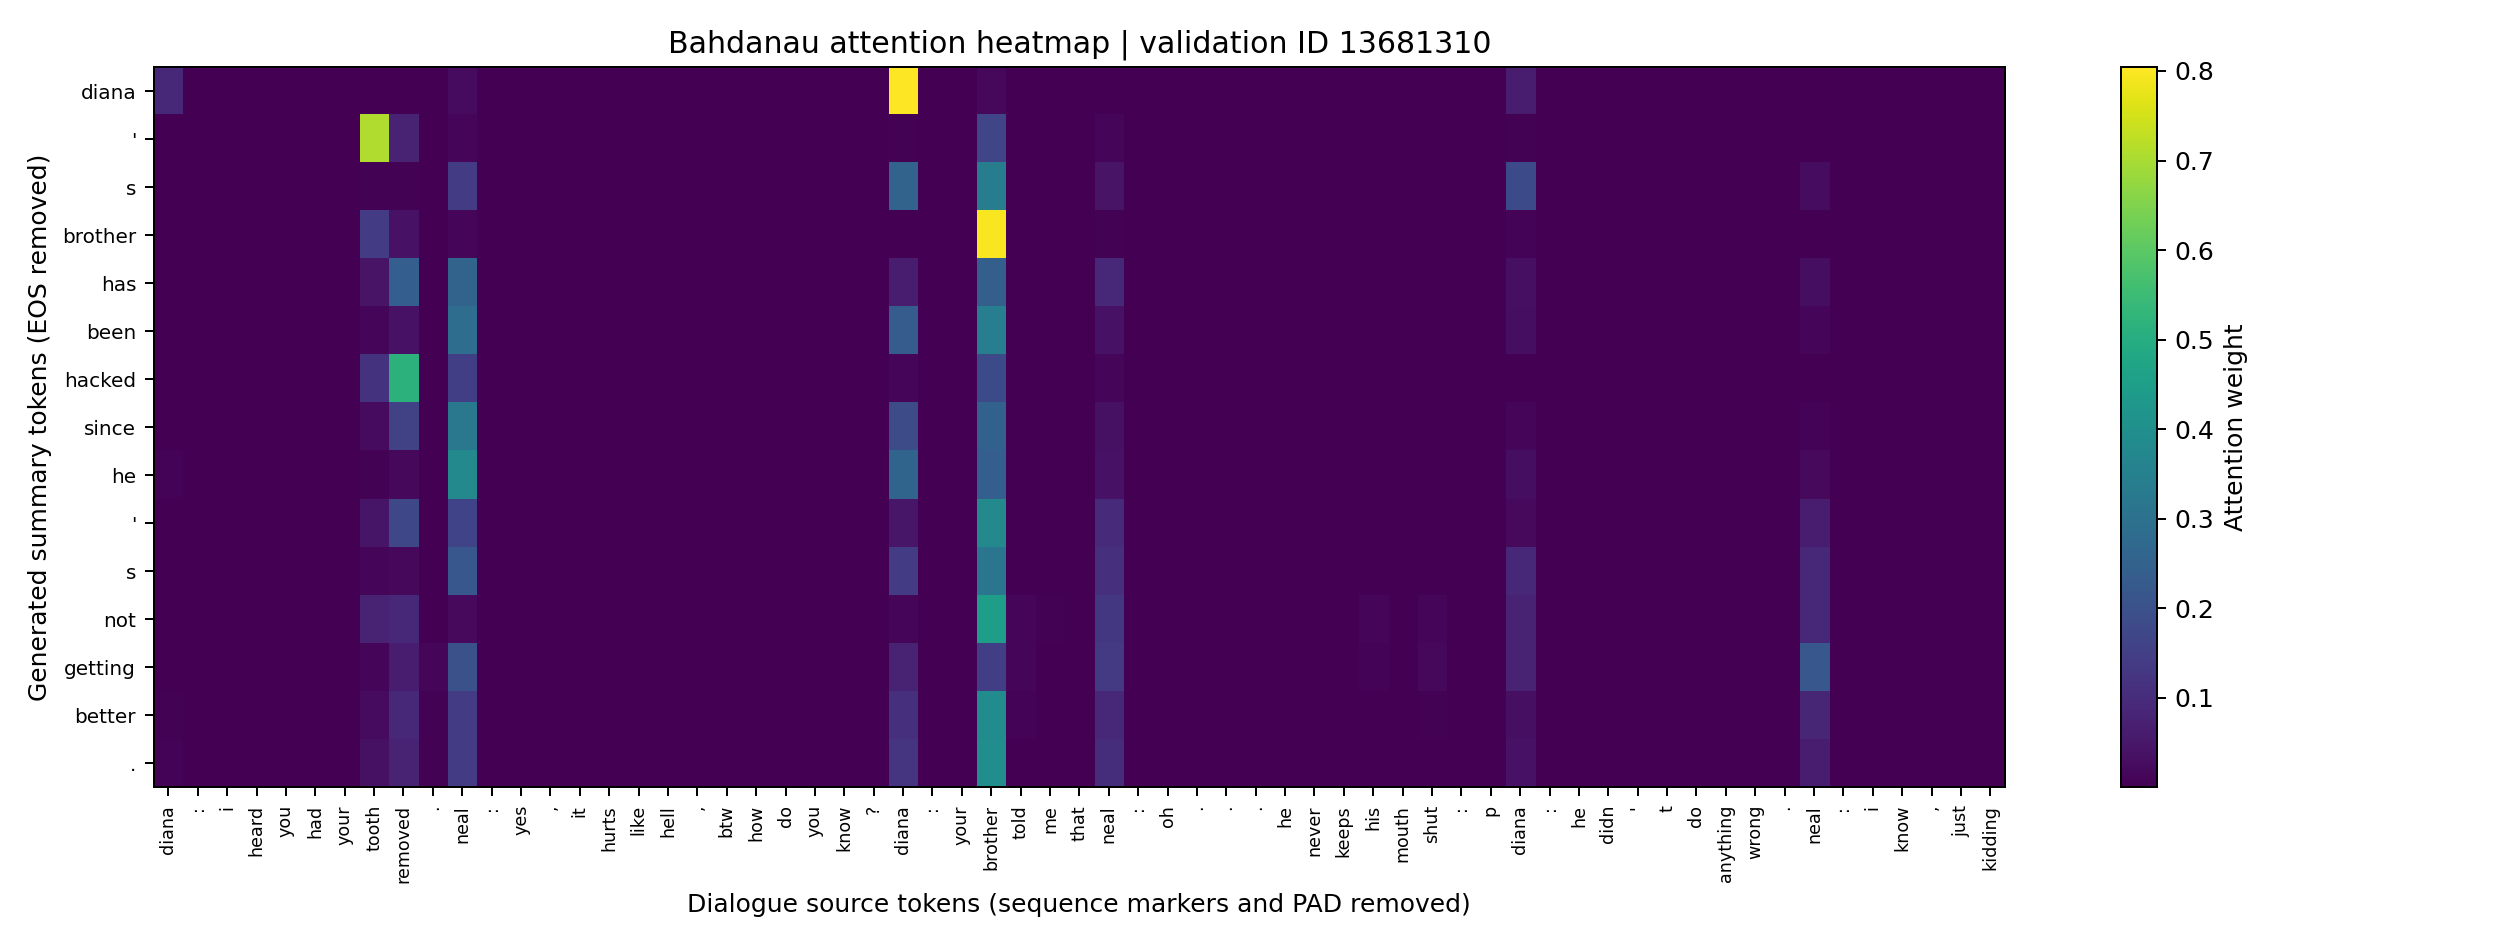


Structured manual-review data: C:\Users\Omar\Desktop\NN Project\results\validation_analysis\qualitative_manual_review_candidates.json
All same-ID greedy comparisons: C:\Users\Omar\Desktop\NN Project\results\validation_analysis\paired_greedy_validation_examples.jsonl
Attention decoding-strategy comparisons: C:\Users\Omar\Desktop\NN Project\results\validation_analysis\attention_decoding_strategy_examples.json


In [2]:
from pathlib import Path
import json
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
ANALYSIS_DIRECTORY = PROJECT_ROOT / 'results' / 'validation_analysis'

with (ANALYSIS_DIRECTORY / 'length_stratified_results.json').open(encoding='utf-8') as source:
    length_analysis = json.load(source)
boundaries = length_analysis['boundaries']
print(
    'Fixed training-derived stored-source boundaries: '
    f"short <= {boundaries['short_max_source_tokens']}; "
    f"medium <= {boundaries['medium_max_source_tokens']}; "
    f"long > {boundaries['medium_max_source_tokens']}"
)
print('\nGroup | n | Mean source length | Vanilla R1/R2/RL | Attention R1/R2/RL')
for row in length_analysis['rows']:
    print(
        f"{row['length_group']} | {row['validation_examples']} | {row['mean_source_token_length']:.2f} | "
        f"{row['vanilla_rouge_1']:.4f}/{row['vanilla_rouge_2']:.4f}/{row['vanilla_rouge_l']:.4f} | "
        f"{row['attention_rouge_1']:.4f}/{row['attention_rouge_2']:.4f}/{row['attention_rouge_l']:.4f}"
    )

display(Image(filename=str(ANALYSIS_DIRECTORY / 'figures' / 'rouge_l_by_length_group.png')))
with (ANALYSIS_DIRECTORY / 'figures' / 'attention_heatmap_manifest.json').open(encoding='utf-8') as source:
    heatmap_manifest = json.load(source)
for item in heatmap_manifest:
    print(f"\nAttention map | validation ID {item['id']} | {item['length_group']} | generated: {item['generated_summary']}")
    display(Image(filename=str(PROJECT_ROOT / item['figure'])))

print('\nStructured manual-review data:', ANALYSIS_DIRECTORY / 'qualitative_manual_review_candidates.json')
print('All same-ID greedy comparisons:', ANALYSIS_DIRECTORY / 'paired_greedy_validation_examples.jsonl')
print('Attention decoding-strategy comparisons:', ANALYSIS_DIRECTORY / 'attention_decoding_strategy_examples.json')

## Final frozen-protocol test evaluation

The test split was evaluated once only after the experimental protocol was frozen. The display cell below is deliberately read-only: it loads the already-saved final artifacts and does not load SAMSum, a model, or a checkpoint. Do not rerun the final-evaluation script or use the test split for further development.

In [1]:
from pathlib import Path
import json

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
RESULTS_DIRECTORY = PROJECT_ROOT / 'results' / 'final_test_evaluation'

with (RESULTS_DIRECTORY / 'final_test_metrics.json').open(encoding='utf-8') as source:
    final_results = json.load(source)

print('Final evaluation protocol:', final_results['protocol'])
print('\nModel | Decoding | R1 | R2 | RL | Gen mean/median | Ref mean/median | EOS % | Max % | Time')
for row in final_results['rows']:
    print(
        f"{row['model']} | {row['decoding']} | {row['rouge_1']:.4f} | "
        f"{row['rouge_2']:.4f} | {row['rouge_l']:.4f} | "
        f"{row['generated_length_mean']:.2f}/{row['generated_length_median']} | "
        f"{row['reference_length_mean']:.2f}/{row['reference_length_median']} | "
        f"{row['eos_percent']:.2f} | {row['hit_max_length_percent']:.2f} | "
        f"{row['decoding_seconds_total']:.2f}s"
    )

with (RESULTS_DIRECTORY / 'frozen_length_stratified_test_results.json').open(encoding='utf-8') as source:
    length_results = json.load(source)
print('\nFrozen source-length boundaries:', length_results['frozen_boundaries'])
print('Group | n | Mean source length | Vanilla R1/R2/RL | Attention R1/R2/RL')
for row in length_results['rows']:
    print(
        f"{row['length_group']} | {row['test_examples']} | {row['mean_source_token_length']:.2f} | "
        f"{row['vanilla_rouge_1']:.4f}/{row['vanilla_rouge_2']:.4f}/{row['vanilla_rouge_l']:.4f} | "
        f"{row['attention_rouge_1']:.4f}/{row['attention_rouge_2']:.4f}/{row['attention_rouge_l']:.4f}"
    )

print('\nSame-ID greedy predictions:', RESULTS_DIRECTORY / 'paired_greedy_test_predictions.jsonl')
print('Same-ID predictions across all decoders:', RESULTS_DIRECTORY / 'same_id_all_decoding_test_predictions.jsonl')

Final evaluation protocol: {'vocabulary': 'deterministically rebuilt from training split only', 'max_generation_length': 50, 'beam_widths': [3, 5], 'beam_scoring': 'sum_log_probability / ((5 + L) / 6) ** 0.6', 'length_penalty_alpha': 0.6, 'length_L': 'excludes <SOS>; includes emitted <EOS>', 'test_note': 'final test evaluation after protocol freeze; no tuning or selection follows'}

Model | Decoding | R1 | R2 | RL | Gen mean/median | Ref mean/median | EOS % | Max % | Time
Vanilla | greedy | 0.1233 | 0.0131 | 0.1075 | 13.60/13 | 23.62/22 | 99.76 | 0.24 | 1.56s
Vanilla | beam-3 | 0.1235 | 0.0163 | 0.1022 | 12.42/9 | 23.62/22 | 99.76 | 0.24 | 52.38s
Vanilla | beam-5 | 0.1062 | 0.0141 | 0.0889 | 11.74/8 | 23.62/22 | 99.76 | 0.24 | 81.36s
Attention | greedy | 0.2838 | 0.0794 | 0.2399 | 15.32/13 | 23.62/22 | 97.56 | 2.44 | 4.03s
Attention | beam-3 | 0.2771 | 0.0835 | 0.2379 | 12.78/10 | 23.62/22 | 98.17 | 1.83 | 81.21s
Attention | beam-5 | 0.2698 | 0.0806 | 0.2339 | 12.41/10 | 23.62/22 | 97.